In [2]:
#!pip install deltalake

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 MB 8.1 MB/s  0:00:06 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 8.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [deltalake]/3 [deltalake]


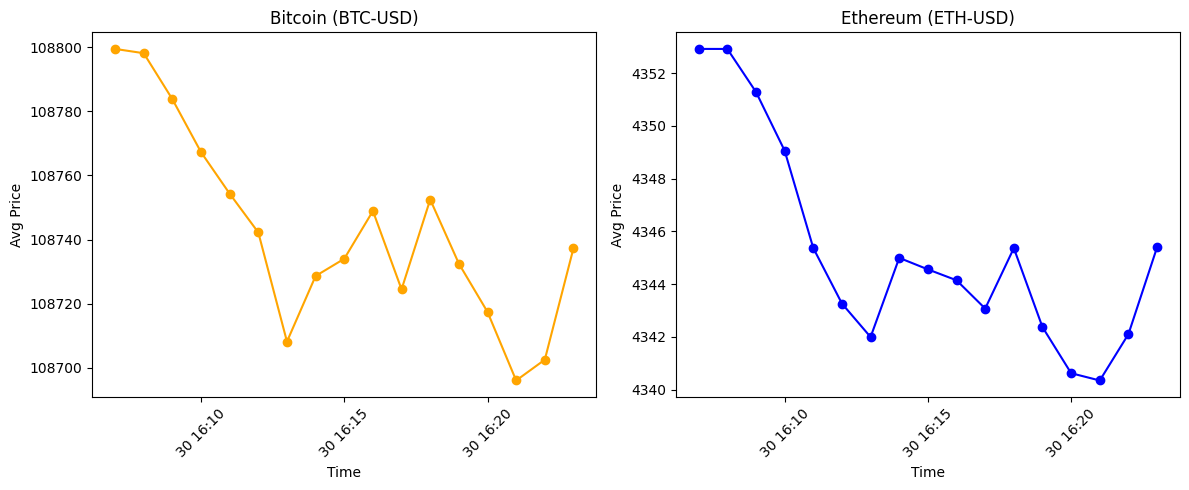

In [ ]:
import time
import matplotlib.pyplot as plt
import pandas as pd
from deltalake import DeltaTable
from IPython.display import clear_output, display
import datetime

start_time = datetime.datetime.now(datetime.UTC) - datetime.timedelta(minutes=10)

TABLE_PATH = "./spark-warehouse/events"

while True:
    # Read Delta table into Pandas
    dt = DeltaTable(TABLE_PATH)
    pdf = dt.to_pandas()

    # Convert window struct into usable timestamps
    pdf["window_end"] = pdf["window"].apply(lambda w: w["end"] if isinstance(w, dict) else w.end).dt.tz_convert('US/Eastern')
    pdf = pdf[pdf['window_end'] > start_time]
    pdf = pdf.sort_values("window_end")

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bitcoin (BTC-USD)
    btc = pdf[pdf["product_id"] == "BTC-USD"]
    if not btc.empty:
        axes[0].plot(btc["window_end"], btc["avg_price"], marker="o", color="orange")
        axes[0].set_title("Bitcoin (BTC-USD)")
        axes[0].set_xlabel("Time")
        axes[0].set_ylabel("Avg Price")
        axes[0].tick_params(axis="x", rotation=45)

    # Ethereum (ETH-USD)
    eth = pdf[pdf["product_id"] == "ETH-USD"]
    if not eth.empty:
        axes[1].plot(eth["window_end"], eth["avg_price"], marker="o", color="blue")
        axes[1].set_title("Ethereum (ETH-USD)")
        axes[1].set_xlabel("Time")
        axes[1].set_ylabel("Avg Price")
        axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()

    # Refresh display in Jupyter
    clear_output(wait=True)
    display(fig)
    plt.close(fig)

    time.sleep(5)  # refresh every 5 seconds